In [2]:

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


In [3]:
df = pd.read_csv('../../DATASETS/banknotes.csv')

In [4]:
df.head()

,Variance,Skewness,Curtosis,Entropy,Class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [5]:
df.describe()

,Variance,Skewness,Curtosis,Entropy,Class
count,1372.000000,1372.000000,1372.000000,1372.000000,1372.000000
mean,0.433735,1.922353,1.397627,-1.191657,0.444606
std,2.842763,5.869047,4.310030,2.101013,0.497103
min,-7.042100,-13.773100,-5.286100,-8.548200,0.000000
25%,-1.773000,-1.708200,-1.574975,-2.413450,0.000000
50%,0.496180,2.319650,0.616630,-0.586650,0.000000
75%,2.821475,6.814625,3.179250,0.394810,1.000000
max,6.824800,12.951600,17.927400,2.449500,1.000000


In [6]:
x=df.drop('Class',axis=1)
y=df['Class']

In [7]:
y.value_counts()

Class
0    762
1    610
Name: count, dtype: int64

In [8]:
y = y.map({0: 'Original', 1: 'Fake'})

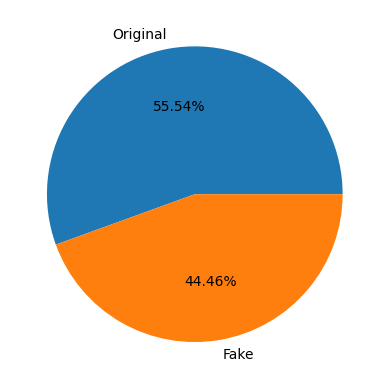

In [12]:
plt.pie(y.value_counts(), labels=y.value_counts().index, autopct='%2.2f%%');

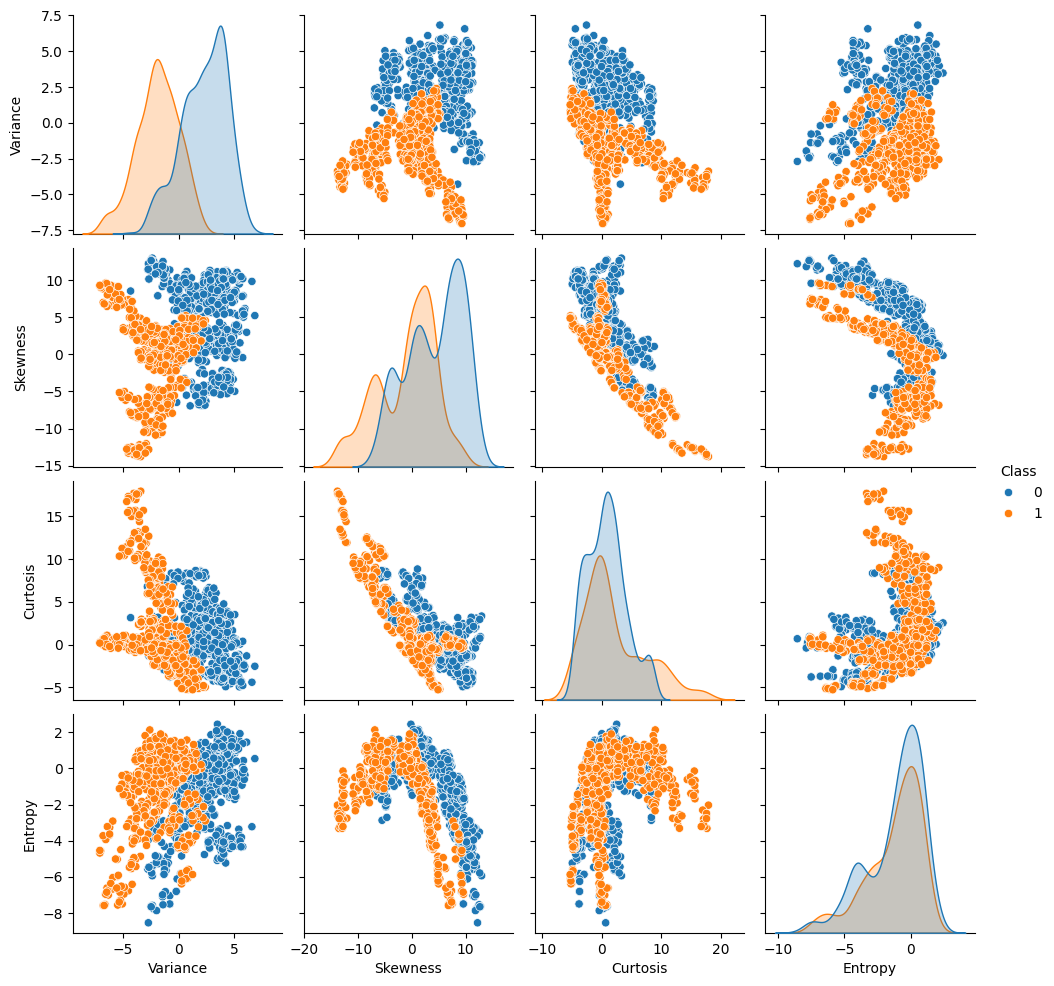

In [13]:
sns.pairplot(df,hue='Class')

### cross validation

In [14]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, )

In [15]:
x_train.shape

(1029, 4)

In [16]:
x_test.shape

(343, 4)

### built the model


In [18]:
from sklearn.tree import DecisionTreeClassifier


In [19]:
dt = DecisionTreeClassifier(random_state=0)

In [20]:
dt.fit(x_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:

from sklearn.metrics import accuracy_score, classification_report

y_pred = dt.predict(x_test)

accuracy_score(y_test, y_pred)

0.9854227405247813

In [ ]:

from sklearn.metrics import confusion_matrix, classification_report

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Confusion Matrix:
[[154   2]
 [  3 184]]

Classification Report:
              precision    recall  f1-score   support

        Fake       0.98      0.99      0.98       156
    Original       0.99      0.98      0.99       187

    accuracy                           0.99       343
   macro avg       0.99      0.99      0.99       343
weighted avg       0.99      0.99      0.99       343



              precision    recall  f1-score   support

        Fake       0.98      0.99      0.98       156
    Original       0.99      0.98      0.99       187

    accuracy                           0.99       343
   macro avg       0.99      0.99      0.99       343
weighted avg       0.99      0.99      0.99       343



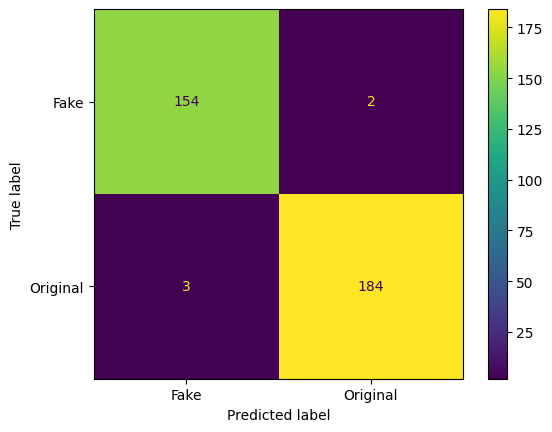

In [23]:

from sklearn.metrics import ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

print(classification_report(y_test, y_pred))

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree


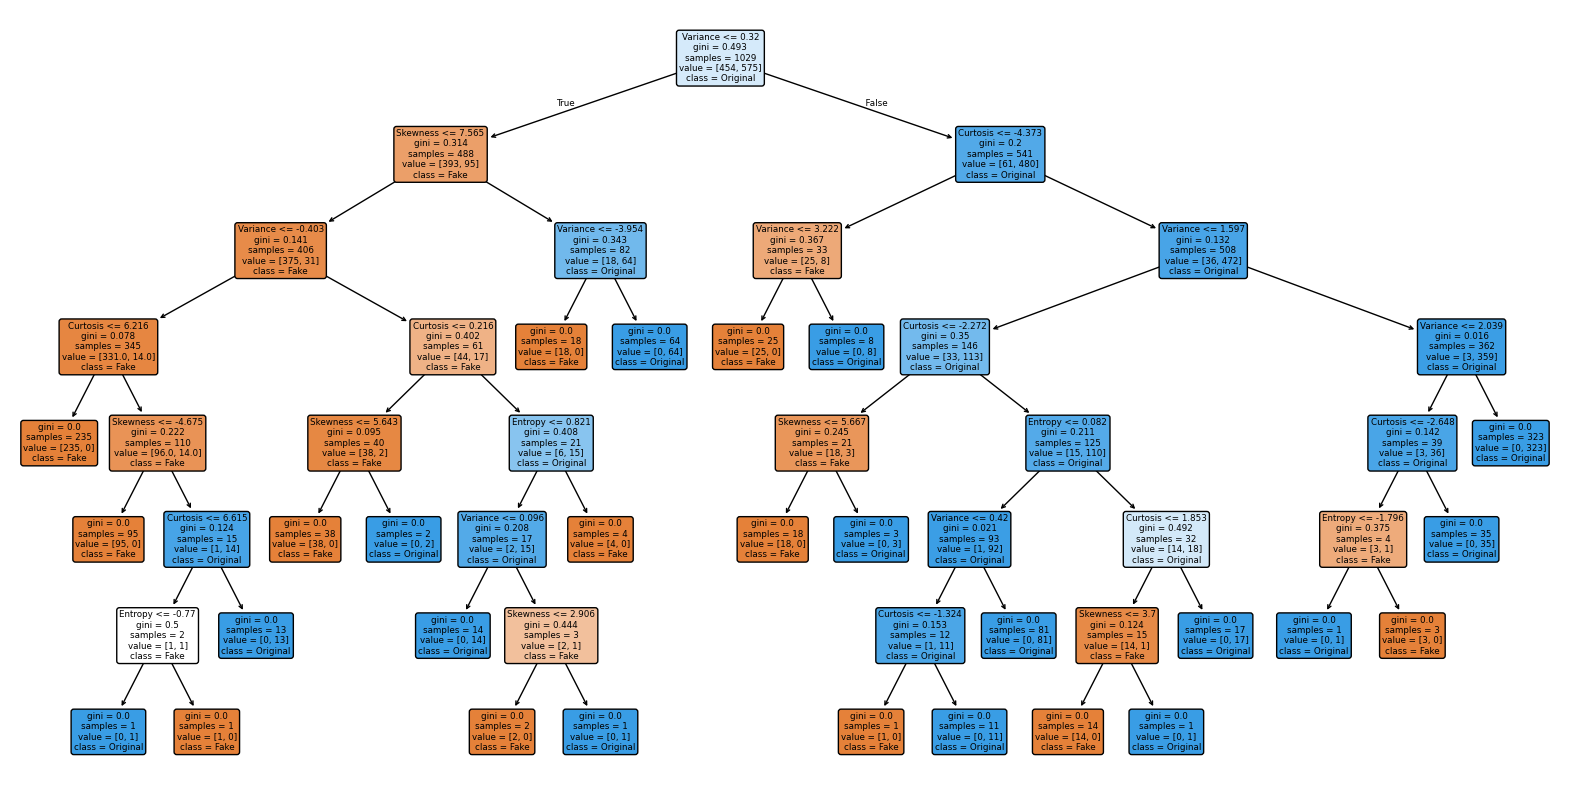

In [30]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(20, 10))

plot_tree(dt, 
          feature_names=x.columns, 
          class_names=['Fake', 'Original'], 
          filled=True, 
          rounded=True)

plt.show()

In [31]:
df.iloc[12,:]

Variance    1.89930
Skewness    7.66250
Curtosis    0.15394
Entropy    -3.11080
Class       0.00000
Name: 12, dtype: float64

In [32]:
newdf = pd.DataFrame(data=[[5.262, 3.9834, -1.5572, 1.0103],
                           [-1.3995, -1.9162, 2.5154, 0.59912],
                           [-2.6989, 12.1984, 0.67661, -8.5482]],
                     columns=x.columns)

In [33]:
newdf

,Variance,Skewness,Curtosis,Entropy
0,5.2620,3.9834,-1.55720,1.01030
1,-1.3995,-1.9162,2.51540,0.59912
2,-2.6989,12.1984,0.67661,-8.54820


In [35]:
dt.predict(newdf)

array(['Original', 'Fake', 'Original'], dtype=object)